In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [12]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [14]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [57]:
features = ["ProductRelated","ProductRelated_Duration","BounceRates","ExitRates","SpecialDay","Month","Region","TrafficType","VisitorType","Weekend"]
target = ["Revenue"]

In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Revenue"] = le.fit_transform(df["Revenue"])
df["Weekend"] = le.fit_transform(df["Weekend"])

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop(["Revenue"],axis=1)
Y = df["Revenue"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

model = DecisionTreeClassifier()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print("accuracy_score:",accuracy_score(Y_pred,Y_test)*100)
print("recall_score:",recall_score(Y_pred,Y_test)*100)
print("f1_score:",f1_score(Y_pred,Y_test)*100)

accuracy_score: 85.72587185725872
recall_score: 57.10843373493976
f1_score: 57.384987893462466


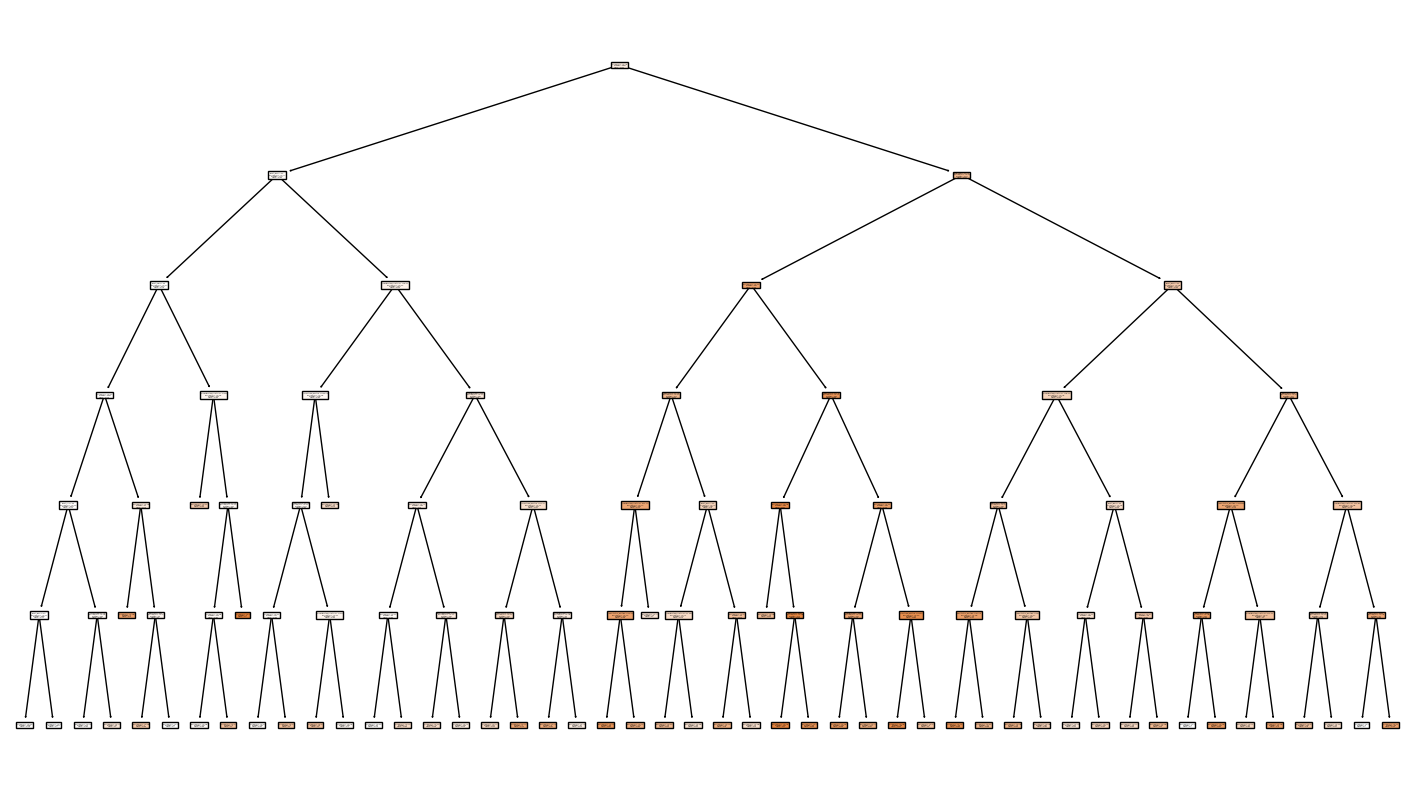

In [108]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True
)

plt.show()

In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

model = DecisionTreeClassifier(max_depth=6)
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print("accuracy_score:",accuracy_score(Y_pred,Y_test)*100)
print("recall_score:",recall_score(Y_pred,Y_test)*100)
print("f1_score:",f1_score(Y_pred,Y_test)*100)

accuracy_score: 89.33495539334956
recall_score: 74.3421052631579
f1_score: 63.21678321678321


In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

model = DecisionTreeClassifier(max_depth=6, min_samples_split=30)
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print("accuracy_score:",accuracy_score(Y_pred,Y_test)*100)
print("recall_score:",recall_score(Y_pred,Y_test)*100)
print("f1_score:",f1_score(Y_pred,Y_test)*100)

accuracy_score: 89.41605839416059
recall_score: 74.35064935064936
f1_score: 63.69958275382476


In [77]:
max_depth = [2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,Y_train)
    acc = model.score(X_test,Y_test)*100
    print(f"for depth={depth}, accuracy={acc}")

for depth=2, accuracy=87.63179237631792
for depth=3, accuracy=88.84833738848337
for depth=4, accuracy=89.29440389294405
for depth=5, accuracy=88.84833738848337
for depth=6, accuracy=89.33495539334956
for depth=7, accuracy=89.01054339010544
for depth=8, accuracy=88.80778588807786
for depth=9, accuracy=87.87510137875101
for depth=10, accuracy=88.07785888077859


In [83]:
min_samples_split = [5,10,15,20,25,30,35,40]
for split in min_samples_split:
    model = DecisionTreeClassifier(min_samples_split=split)
    model.fit(X_train,Y_train)
    acc = model.score(X_test,Y_test)*100
    print(f"for split={split}, accuracy={acc}")

for split=5, accuracy=86.61800486618006
for split=10, accuracy=86.94241686942416
for split=15, accuracy=87.87510137875101
for split=20, accuracy=88.07785888077859
for split=25, accuracy=88.3617193836172
for split=30, accuracy=88.3617193836172
for split=35, accuracy=87.95620437956204
for split=40, accuracy=88.19951338199513


In [100]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

model = DecisionTreeRegressor()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print("r2_score:",r2_score(Y_pred,Y_test)*100)
print("mean_squared_error:",mean_squared_error(Y_pred,Y_test)*100)

r2_score: -5.4582836465315365
mean_squared_error: 14.760746147607462


In [102]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

model = DecisionTreeRegressor(max_depth=6)
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print("r2_score:",r2_score(Y_pred,Y_test)*100)
print("mean_squared_error:",mean_squared_error(Y_pred,Y_test)*100)

r2_score: -16.483291503850907
mean_squared_error: 7.872005444671153


In [104]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

model = DecisionTreeRegressor(max_depth=6, min_samples_split=30)
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print("r2_score:",r2_score(Y_pred,Y_test)*100)
print("mean_squared_error:",mean_squared_error(Y_pred,Y_test)*100)

r2_score: -16.3830759734241
mean_squared_error: 7.819286045691644
